In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns          



ModuleNotFoundError: No module named 'yfinance'

In [2]:
!pip install yfinance



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import yfinance as yf


ModuleNotFoundError: No module named 'yfinance'

In [4]:
pip install ipykernel

Note: you may need to restart the kernel to use updated packages.


In [5]:
python -m ipykernel install --user --name=thesis_env

SyntaxError: invalid syntax (<ipython-input-5-5b05acf83d37>, line 1)

In [1]:
import yfinance as yf

In [2]:
%pip install yfinance


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import yfinance as yf

In [2]:
assets = ["AAPL","MSFT","SPY","QQQ","TSLA"]

data = yf.download(assets, start="2015-01-01")["Adj Close"]

data.head()

[*********************100%***********************]  5 of 5 completed


KeyError: 'Adj Close'

In [3]:
assets = ["AAPL","MSFT","SPY","QQQ","TSLA"]

data = yf.download(assets, start="2015-01-01")

data = data["Close"]

data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,MSFT,QQQ,SPY,TSLA
Date,,,,,
2015-01-02,24.214895,39.767677,94.784424,170.589630,14.620667
2015-01-05,23.532726,39.401985,93.394066,167.508850,14.006000
2015-01-06,23.534933,38.823677,92.141808,165.931076,14.085333
2015-01-07,23.864948,39.316944,93.329597,167.998734,14.063333
2015-01-08,24.781889,40.473564,95.115898,170.979874,14.041333


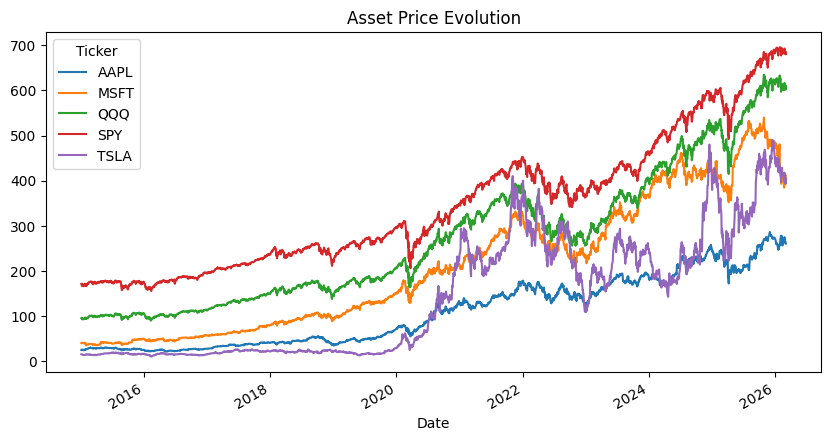

In [7]:
import matplotlib.pyplot as plt

data.plot(figsize=(10,5))
plt.title("Asset Price Evolution")
plt.show()

In [8]:
import numpy as np

returns = np.log(data / data.shift(1))

returns = returns.dropna()

returns.head()

Ticker,AAPL,MSFT,QQQ,SPY,TSLA
Date,,,,,
2015-01-05,-0.028576,-0.009238,-0.014777,-0.018225,-0.042950
2015-01-06,0.000094,-0.014786,-0.013499,-0.009464,0.005648
2015-01-07,0.013925,0.012625,0.012809,0.012384,-0.001563
2015-01-08,0.037702,0.028993,0.018959,0.017589,-0.001566
2015-01-09,0.001072,-0.008441,-0.006604,-0.008045,-0.018981


In [9]:
mean_returns = returns.mean()

cov_matrix = returns.cov()

mean_returns, cov_matrix

(Ticker
 AAPL    0.000846
 MSFT    0.000831
 QQQ     0.000662
 SPY     0.000493
 TSLA    0.001183
 dtype: float64,
 Ticker      AAPL      MSFT       QQQ       SPY      TSLA
 Ticker                                                  
 AAPL    0.000329  0.000201  0.000200  0.000151  0.000283
 MSFT    0.000201  0.000291  0.000198  0.000148  0.000251
 QQQ     0.000200  0.000198  0.000191  0.000144  0.000281
 SPY     0.000151  0.000148  0.000144  0.000125  0.000200
 TSLA    0.000283  0.000251  0.000281  0.000200  0.001303)

In [10]:
num_assets = len(mean_returns)

num_assets

5

In [11]:
weights = np.random.random(num_assets)

weights = weights / np.sum(weights)

weights

array([0.2023871 , 0.13716732, 0.0240915 , 0.44498591, 0.19136817])

In [12]:
portfolio_return = np.sum(mean_returns * weights) * 252

portfolio_return

np.float64(0.18826195035786863)

In [13]:
portfolio_volatility = np.sqrt(
    np.dot(weights.T, np.dot(cov_matrix * 252, weights))
)

portfolio_volatility

np.float64(0.23868118834531046)

In [14]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

num_portfolios = 5000

results = np.zeros((3, num_portfolios))

weights_record = []

for i in range(num_portfolios):

    weights = np.random.random(len(mean_returns))
    weights /= np.sum(weights)

    weights_record.append(weights)

    portfolio_return = np.sum(mean_returns * weights) * 252

    portfolio_std = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix * 252, weights))
    )

    sharpe_ratio = portfolio_return / portfolio_std

    results[0,i] = portfolio_std
    results[1,i] = portfolio_return
    results[2,i] = sharpe_ratio

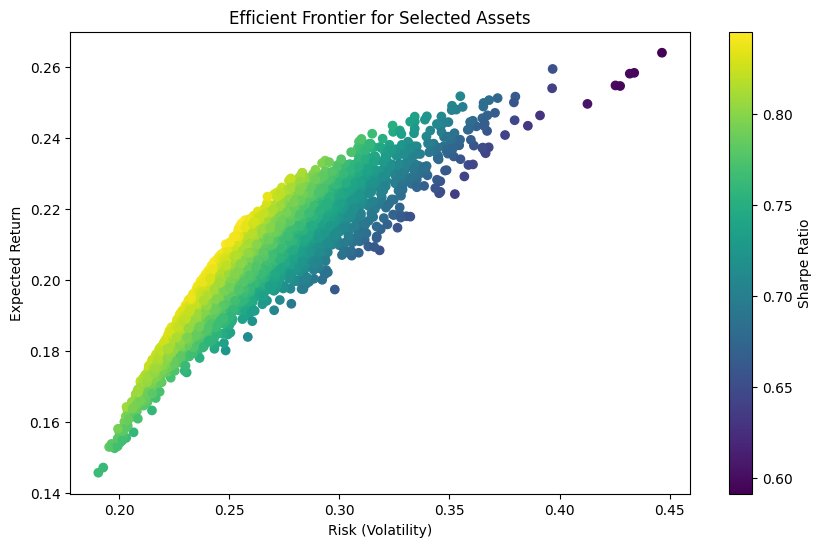

In [15]:
plt.figure(figsize=(10,6))

plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap="viridis")

plt.xlabel("Risk (Volatility)")
plt.ylabel("Expected Return")

plt.colorbar(label="Sharpe Ratio")

plt.title("Efficient Frontier for Selected Assets")

plt.show()

In [16]:
max_sharpe_idx = np.argmax(results[2])
max_sharpe_idx

np.int64(152)

In [17]:
optimal_return = results[1, max_sharpe_idx]
optimal_risk = results[0, max_sharpe_idx]

optimal_return, optimal_risk

(np.float64(0.21003639089894427), np.float64(0.24849831155081614))

In [18]:
optimal_weights = weights_record[max_sharpe_idx]

optimal_weights

array([0.38078059, 0.47961696, 0.0381112 , 0.04736653, 0.05412471])

In [19]:
portfolio = pd.DataFrame({
    "Asset": assets,
    "Weight": optimal_weights
})

portfolio

NameError: name 'pd' is not defined

In [19]:
portfolio = pd.DataFrame({
    "Asset": assets,
    "Weight": optimal_weights
})

portfolio

NameError: name 'pd' is not defined

In [20]:
import pandas as pd

In [21]:
portfolio = pd.DataFrame({
    "Asset": assets,
    "Weight": optimal_weights
})

portfolio

,Asset,Weight
0,AAPL,0.380781
1,MSFT,0.479617
2,SPY,0.038111
3,QQQ,0.047367
4,TSLA,0.054125


In [22]:
portfolio_returns = returns.dot(optimal_weights)

portfolio_returns.head()

Date
2015-01-05   -0.019063
2015-01-06   -0.007713
2015-01-07    0.012348
2015-01-08    0.029733
2015-01-09   -0.005300
dtype: float64

In [23]:
cumulative_returns = (1 + portfolio_returns).cumprod()

cumulative_returns.head()

Date
2015-01-05    0.980937
2015-01-06    0.973371
2015-01-07    0.985390
2015-01-08    1.014689
2015-01-09    1.009311
dtype: float64

In [24]:
spy = yf.download("SPY", start="2015-01-01")["Close"]

spy_returns = np.log(spy / spy.shift(1)).dropna()

spy_cumulative = (1 + spy_returns).cumprod()

[*********************100%***********************]  1 of 1 completed


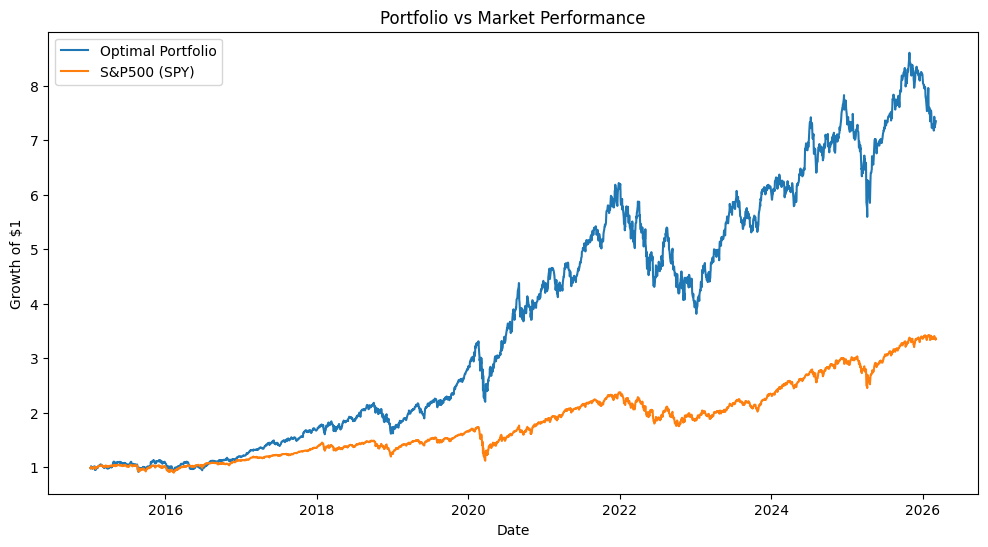

In [25]:
plt.figure(figsize=(12,6))

plt.plot(cumulative_returns, label="Optimal Portfolio")
plt.plot(spy_cumulative, label="S&P500 (SPY)")

plt.title("Portfolio vs Market Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()

plt.show()

In [26]:
portfolio_sharpe = portfolio_returns.mean() / portfolio_returns.std() * np.sqrt(252)

portfolio_volatility = portfolio_returns.std() * np.sqrt(252)

portfolio_return = portfolio_returns.mean() * 252

portfolio_return, portfolio_volatility, portfolio_sharpe

(np.float64(0.21003639089894424),
 np.float64(0.24849831155081617),
 np.float64(0.8452226077036877))

In [27]:
cumulative_returns = (1 + portfolio_returns).cumprod()

cumulative_returns.head()

Date
2015-01-05    0.980937
2015-01-06    0.973371
2015-01-07    0.985390
2015-01-08    1.014689
2015-01-09    1.009311
dtype: float64

In [28]:
spy = yf.download("SPY", start="2015-01-01")["Close"]

spy_returns = np.log(spy / spy.shift(1))

spy_returns = spy_returns.dropna()

spy_cumulative = (1 + spy_returns).cumprod()

[*********************100%***********************]  1 of 1 completed


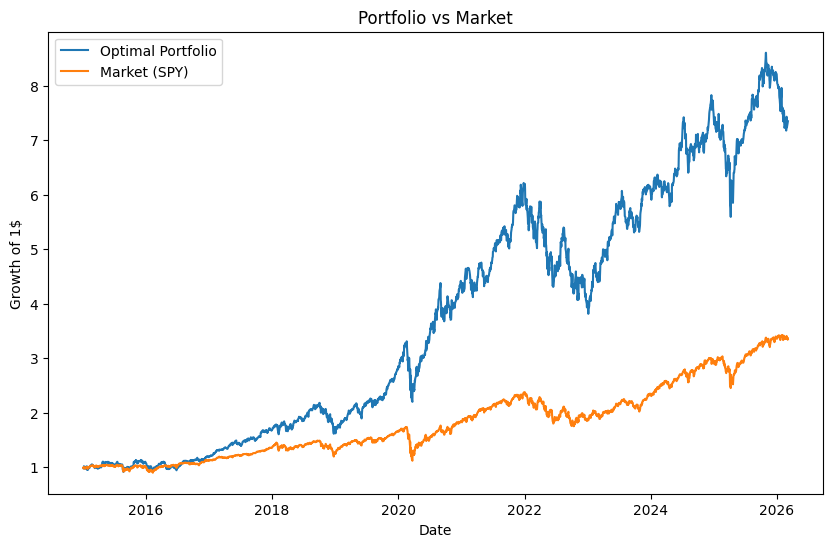

In [29]:
plt.figure(figsize=(10,6))

plt.plot(cumulative_returns, label="Optimal Portfolio")
plt.plot(spy_cumulative, label="Market (SPY)")

plt.xlabel("Date")
plt.ylabel("Growth of 1$")

plt.title("Portfolio vs Market")

plt.legend()

plt.show()

In [30]:
annual_return = portfolio_returns.mean() * 252

annual_volatility = portfolio_returns.std() * np.sqrt(252)

sharpe_ratio = annual_return / annual_volatility

annual_return, annual_volatility, sharpe_ratio

(np.float64(0.21003639089894424),
 np.float64(0.24849831155081617),
 np.float64(0.8452226077036876))

In [31]:
running_max = cumulative_returns.cummax()

drawdown = cumulative_returns / running_max - 1

max_drawdown = drawdown.min()

max_drawdown

np.float64(-0.38648210531297356)

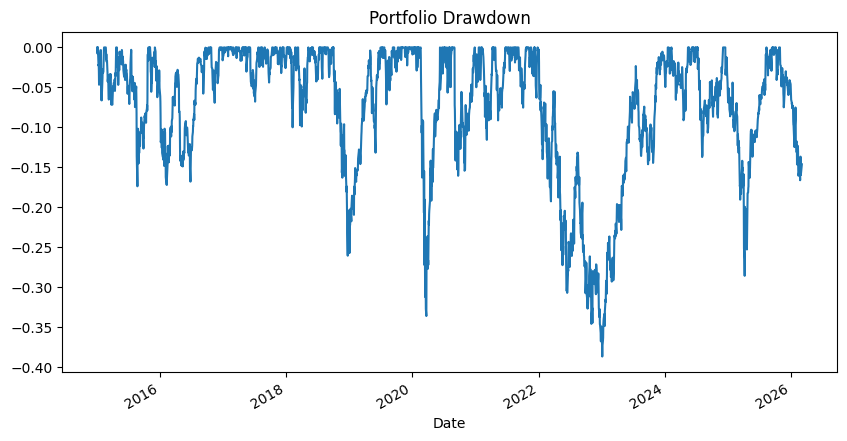

In [32]:
plt.figure(figsize=(10,5))

drawdown.plot()

plt.title("Portfolio Drawdown")

plt.show()

Text(0.5, 1.0, 'Rolling Volatility (30 days)')

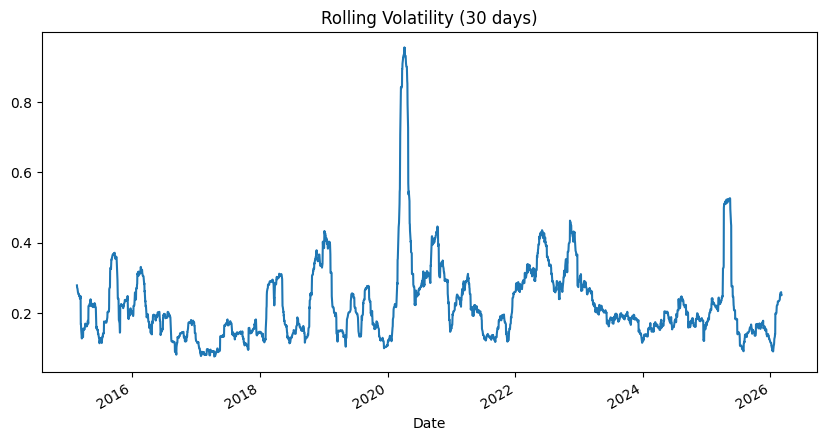

In [33]:
rolling_vol = portfolio_returns.rolling(30).std() * np.sqrt(252)

rolling_vol.plot(figsize=(10,5))

plt.title("Rolling Volatility (30 days)")

Text(0.5, 1.0, 'Correlation Matrix')

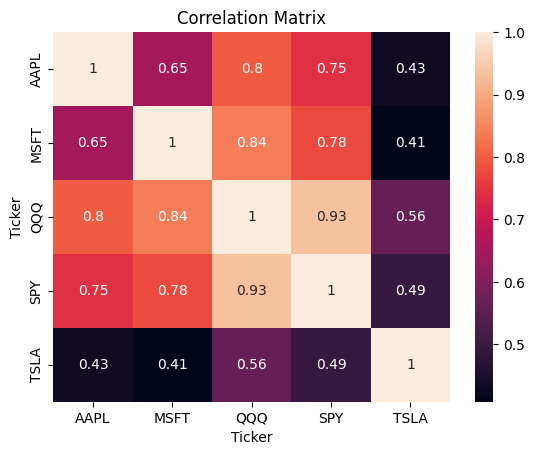

In [34]:
import seaborn as sns

corr_matrix = returns.corr()

sns.heatmap(corr_matrix, annot=True)

plt.title("Correlation Matrix")

Text(0.5, 1.0, 'Distribution of Portfolio Returns')

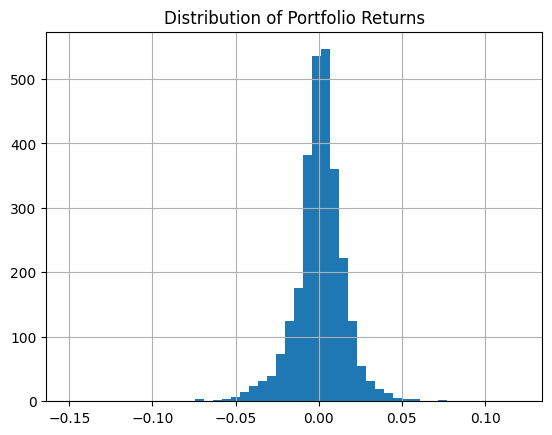

In [35]:
portfolio_returns.hist(bins=50)

plt.title("Distribution of Portfolio Returns")

In [36]:
price = yf.download("SPY", start="2015-01-01")["Close"]

ma_short = price.rolling(50).mean()

ma_long = price.rolling(200).mean()

[*********************100%***********************]  1 of 1 completed


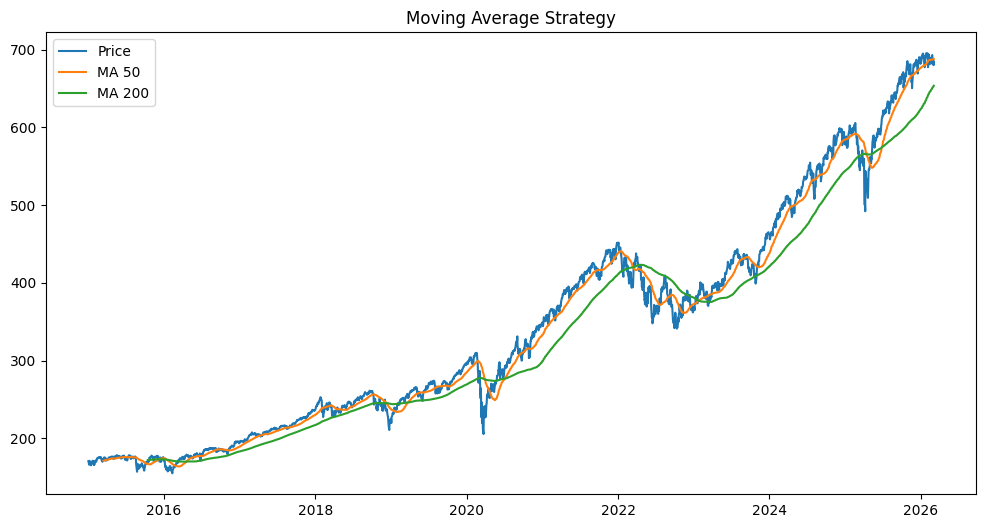

In [37]:
plt.figure(figsize=(12,6))

plt.plot(price, label="Price")

plt.plot(ma_short, label="MA 50")

plt.plot(ma_long, label="MA 200")

plt.legend()

plt.title("Moving Average Strategy")

plt.show()

In [38]:
signal = (ma_short > ma_long).astype(int)

signal.head()

Ticker,SPY
Date,
2015-01-02,0
2015-01-05,0
2015-01-06,0
2015-01-07,0
2015-01-08,0


In [39]:
returns = np.log(price / price.shift(1))

strategy_returns = returns * signal.shift(1)

strategy_returns = strategy_returns.dropna()

In [40]:
strategy_cumulative = (1 + strategy_returns).cumprod()

market_cumulative = (1 + returns).cumprod()

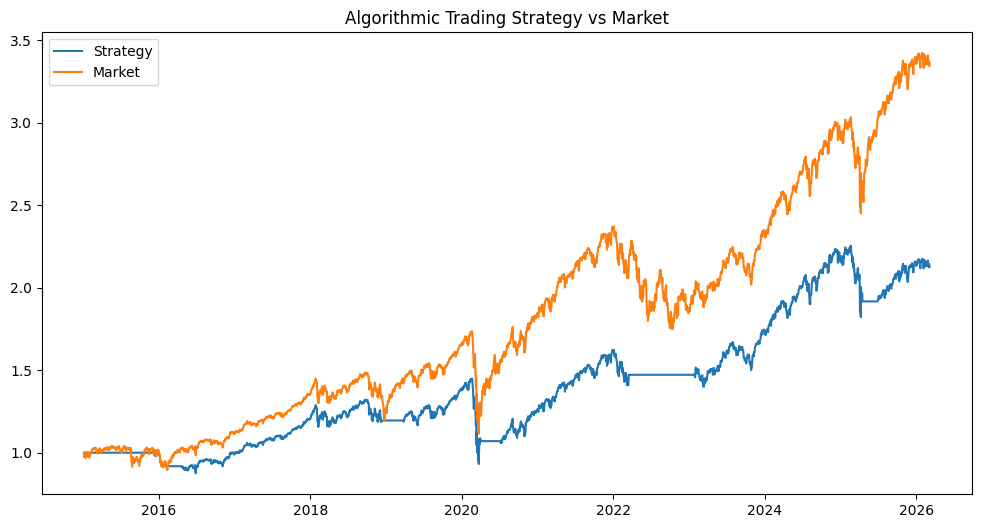

In [41]:
plt.figure(figsize=(12,6))

plt.plot(strategy_cumulative, label="Strategy")

plt.plot(market_cumulative, label="Market")

plt.legend()

plt.title("Algorithmic Trading Strategy vs Market")

plt.show()

In [42]:
volatility = returns.rolling(30).std() * np.sqrt(252)

volatility.head()

Ticker,SPY
Date,
2015-01-02,NaN
2015-01-05,NaN
2015-01-06,NaN
2015-01-07,NaN
2015-01-08,NaN


Text(0.5, 1.0, 'Rolling Volatility (30 days)')

<Figure size 1200x500 with 0 Axes>

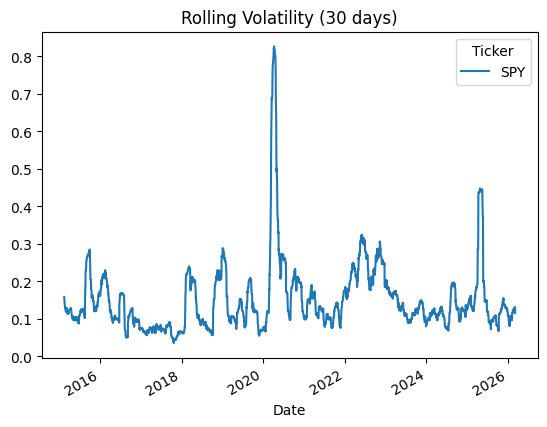

In [43]:
plt.figure(figsize=(12,5))

volatility.plot()

plt.title("Rolling Volatility (30 days)")

In [44]:
vol_mean = volatility.mean()

vol_signal = (volatility < vol_mean).astype(int)

vol_signal.head()

Ticker,SPY
Date,
2015-01-02,0
2015-01-05,0
2015-01-06,0
2015-01-07,0
2015-01-08,0


In [45]:
vol_strategy_returns = returns * vol_signal.shift(1)

vol_strategy_returns = vol_strategy_returns.dropna()

In [46]:
vol_strategy_cumulative = (1 + vol_strategy_returns).cumprod()

market_cumulative = (1 + returns).cumprod()

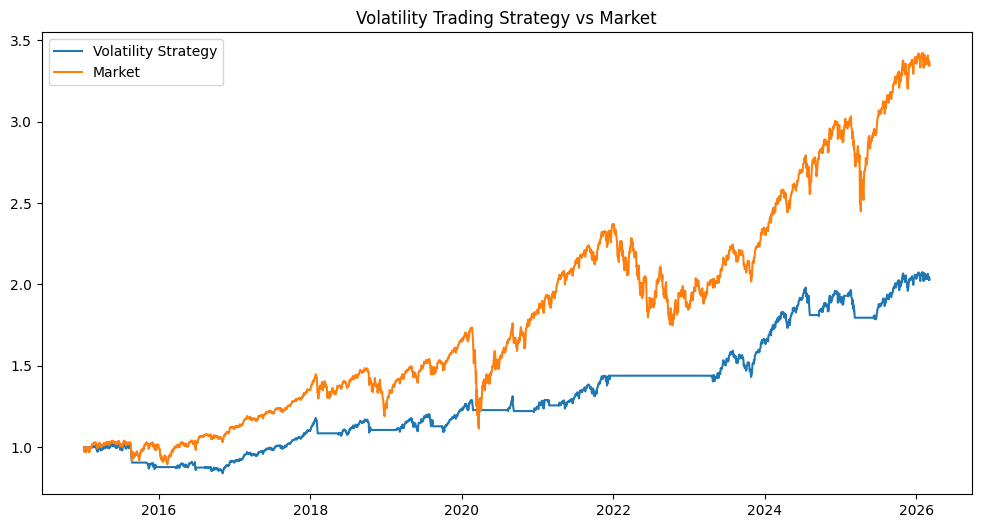

In [47]:
plt.figure(figsize=(12,6))

plt.plot(vol_strategy_cumulative, label="Volatility Strategy")

plt.plot(market_cumulative, label="Market")

plt.legend()

plt.title("Volatility Trading Strategy vs Market")

plt.show()

In [48]:
annual_return = vol_strategy_returns.mean() * 252

annual_volatility = vol_strategy_returns.std() * np.sqrt(252)

sharpe_ratio = annual_return / annual_volatility

annual_return, annual_volatility, sharpe_ratio

(Ticker
 SPY    0.067979
 dtype: float64,
 Ticker
 SPY    0.093857
 dtype: float64,
 Ticker
 SPY    0.724277
 dtype: float64)